# Time series and correlation 
@daniela.leite.correa

In [34]:
from pydap.client import open_url
from netCDF4 import Dataset
import datetime as date
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import xarray as xr
from netCDF4 import Dataset , num2date
from scipy.io import netcdf_file as netcdf
import matplotlib.pyplot as plt
import numpy as np
from datetime import date, timedelta, datetime
import numpy.ma as ma


# 8s 30W

In [2]:
#satelite = xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/PIRATA/sst_boia.nc')
satelite = xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/PIRATA/8s30.nc')

In [3]:
buoy = xr.open_dataset('http://goosbrasil.org:8080/pirata/B8s30w.nc')


In [4]:
buoy = buoy.where(buoy>0)
satelite = satelite.where(satelite>0)

In [5]:
temp_b = buoy.variables['temperature'][:]
time_b = buoy.variables['time'][134:5612]  # iguala o tempo da boia com a do satelite 

temp_s = satelite.variables['sst'][:]
time_s = satelite.variables['time'][:]

In [6]:
sst1_s = np.squeeze(temp_s[:,0,1])  #redimensionar satelite, coloquei lat e lon iguais da boia 
sst1_b = np.squeeze(temp_b[134:5612,0]) #escolhi a primeira profundidade que é 1 metro

In [7]:
print(time_b.shape)
print(sst1_b.shape)
print(time_s.shape)
print(sst1_s.shape)

(5478,)
(5478,)
(5478,)
(5478,)


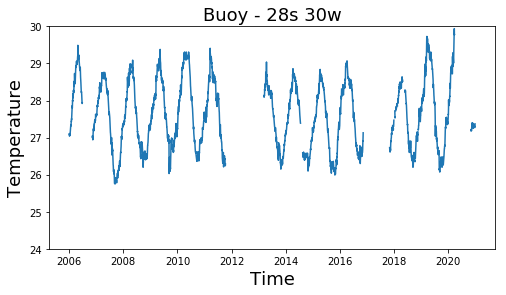

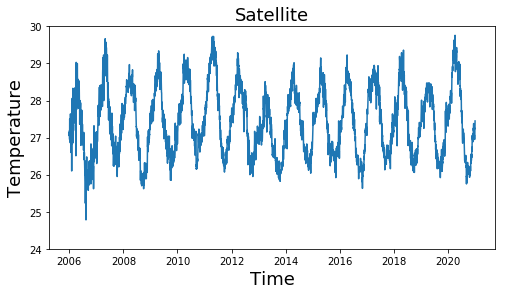

In [59]:
plt.rcParams["figure.figsize"] = (8,9)

plt.subplot(2, 1, 1)
plt.plot(time_b,sst1_b,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Buoy - 8s 30w', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

plt.subplot(2, 1, 2)
plt.plot(time_s,sst1_s,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

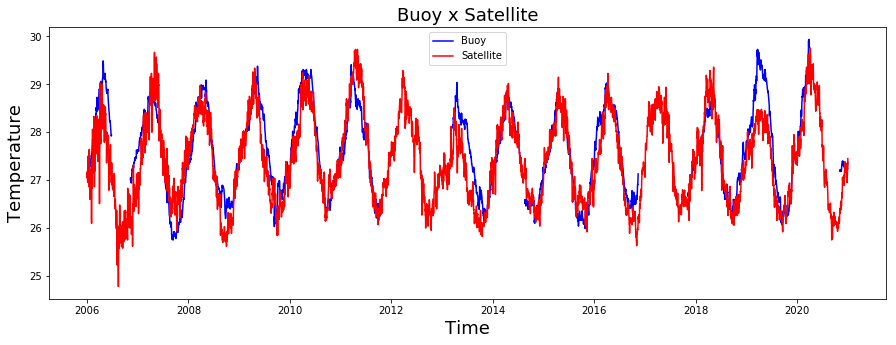

In [9]:
plt.rcParams["figure.figsize"] = (15,5)

#fig = plt.figure()

plt.plot_date(time_b,sst1_b, 'b-', label = 'Buoy')
plt.plot_date(time_s,sst1_s, 'r-', label = 'Satellite')
plt.legend(loc='upper center')

plt.title('Buoy x Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)

plt.show()

In [10]:
## calcular correlação das temperaturas
print(sst1_b.shape)
print(sst1_s.shape)

(5478,)
(5478,)


In [11]:
x = sst1_b 
y = sst1_s

In [14]:
print(ma.corrcoef(ma.masked_invalid(x), ma.masked_invalid(y)))  #ignora os nan 


[[1.0 0.8764318137104511]
 [0.8764318137104511 1.0]]


In [32]:

print(ma.cov(ma.masked_invalid(x), ma.masked_invalid(y)))  #ignora os nan 


[[0.833255388603673 0.711243737228174]
 [0.711243737228174 0.7903555590918725]]


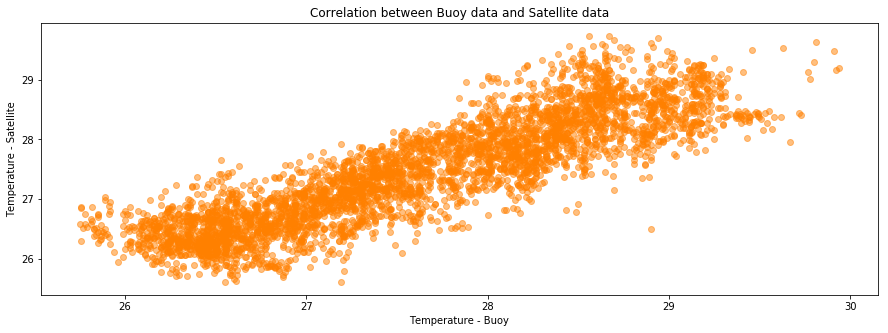

In [57]:
colors = (1.0, 0.5, 0.0)

plt.scatter(x, y, c=colors, alpha=0.5) 


plt.xlabel('Temperature - Buoy')
plt.ylabel('Temperature - Satellite')
plt.title('Correlation between Buoy data and Satellite data')
plt.show()

# 14s 32w

In [2]:
satelite2 = xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/PIRATA/14s32.nc')

In [5]:
buoy2 = xr.open_dataset('http://goosbrasil.org:8080/pirata/B14s32w.nc')


In [6]:
buoy2 = buoy2.where(buoy2>0)
satelite2 = satelite2.where(satelite2>0)

In [11]:
temp_b2 = buoy2.variables['temperature'][:]
time_b2 = buoy2.variables['time'][134:5612]  # iguala o tempo da boia com a do satelite 

temp_s2 = satelite2.variables['sst'][:]
time_s2 = satelite2.variables['time'][:]

In [12]:
sst1_s2 = np.squeeze(temp_s2[:,5,5])  #redimensionar satelite, coloquei lat e lon iguais da boia 
sst1_b2 = np.squeeze(temp_b2[134:5612,0]) #escolhi a primeira profundidade que é 1 metro

In [13]:
print(time_b2.shape)
print(sst1_b2.shape)
print(time_s2.shape)
print(sst1_s2.shape)

(5478,)
(5478,)
(5478,)
(5478,)


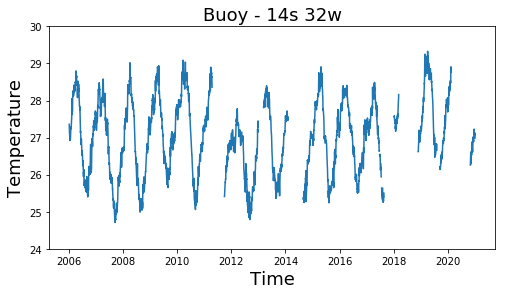

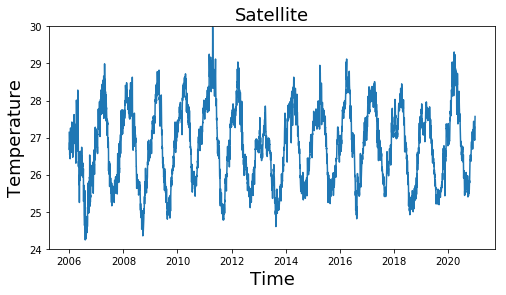

In [14]:
plt.rcParams["figure.figsize"] = (8,9)

plt.subplot(2, 1, 1)
plt.plot(time_b2,sst1_b2,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Buoy - 14s 32w', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

plt.subplot(2, 1, 2)
plt.plot(time_s2,sst1_s2,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

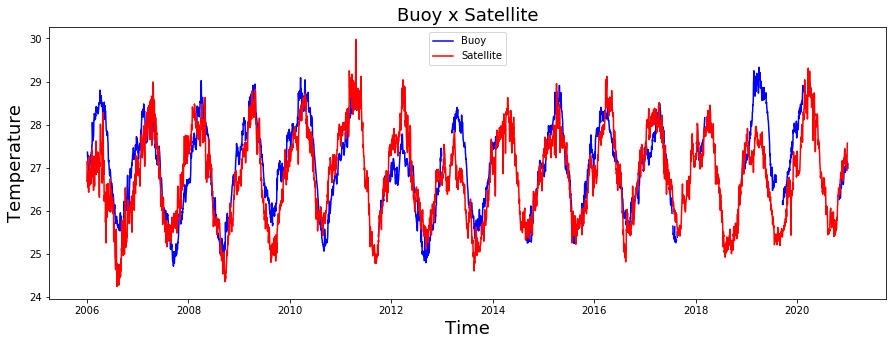

In [23]:
plt.rcParams["figure.figsize"] = (15,5)

#fig = plt.figure()

plt.plot_date(time_b2,sst1_b2, 'b-', label = 'Buoy')
plt.plot_date(time_s2,sst1_s2, 'r-', label = 'Satellite')
plt.legend(loc='upper center')

plt.title('Buoy x Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)

plt.show()

In [15]:
x2 = sst1_b2
y2 = sst1_s2

In [16]:
print(ma.corrcoef(ma.masked_invalid(x2), ma.masked_invalid(y2)))  #ignora os nan 


[[1.0 0.7996263935291225]
 [0.7996263935291225 1.0]]


In [17]:
print(ma.cov(ma.masked_invalid(x2), ma.masked_invalid(y2)))  #ignora os nan 


[[1.0178329494342648 0.7926694954647359]
 [0.7926694954647359 0.9654583519832254]]


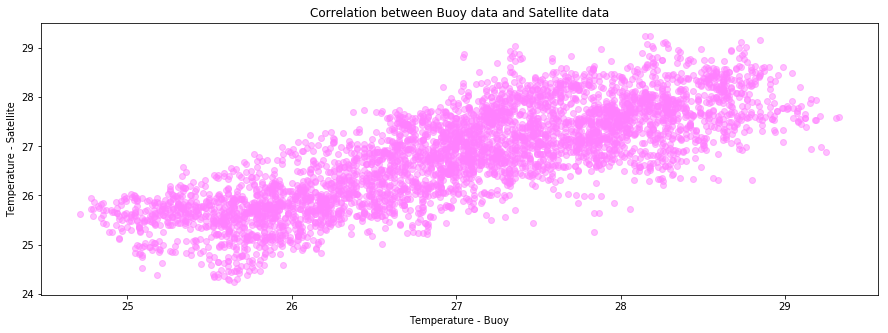

In [22]:
plt.rcParams["figure.figsize"] = (15,5)

colors = (1.0, 0.5, 1.0)

plt.scatter(x2, y2, c=colors, alpha=0.5) 


plt.xlabel('Temperature - Buoy')
plt.ylabel('Temperature - Satellite')
plt.title('Correlation between Buoy data and Satellite data')
plt.show()

# 0N 35W

In [48]:
satelite3 = xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/PIRATA/0n35.nc')

In [49]:
buoy3 = xr.open_dataset('http://goosbrasil.org:8080/pirata/B0n35w.nc')


In [50]:
buoy3 = buoy3.where(buoy3>0)
satelite3 = satelite3.where(satelite3>0)

In [76]:
temp_b3 = buoy3.variables['temperature'][:]
time_b3 = buoy3.variables['time'][345:5458]  # iguala o tempo da boia com a do satelite 

temp_s3 = satelite3.variables['sst'][:]
time_s3 = satelite3.variables['time'][:]

In [77]:
time_b3

<xarray.IndexVariable 'time' (time: 5113)>
array(['1999-01-01T12:00:00.000000000', '1999-01-02T12:00:00.000000000',
       '1999-01-03T12:00:00.000000000', ..., '2012-12-28T12:00:00.000000000',
       '2012-12-29T12:00:00.000000000', '2012-12-30T12:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:  Time

In [78]:
sst1_s3 = np.squeeze(temp_s3[:,3,2])  #redimensionar satelite, coloquei lat e lon iguais da boia 
sst1_b3 = np.squeeze(temp_b3[345:5458,0]) #escolhi a primeira profundidade que é 1 metro

In [79]:
print(time_b3.shape)
print(sst1_b3.shape)
print(time_s3.shape)
print(sst1_s3.shape)

(5113,)
(5113,)
(5113,)
(5113,)


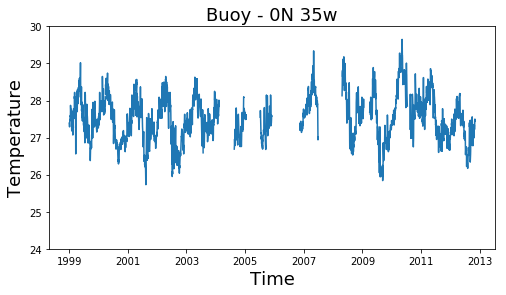

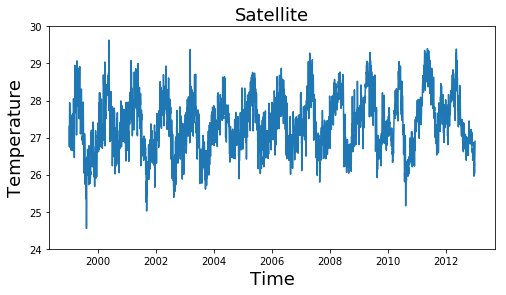

In [80]:
plt.rcParams["figure.figsize"] = (8,9)

plt.subplot(2, 1, 1)
plt.plot(time_b3,sst1_b3,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Buoy - 0N 35w', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

plt.subplot(2, 1, 2)
plt.plot(time_s3,sst1_s3,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

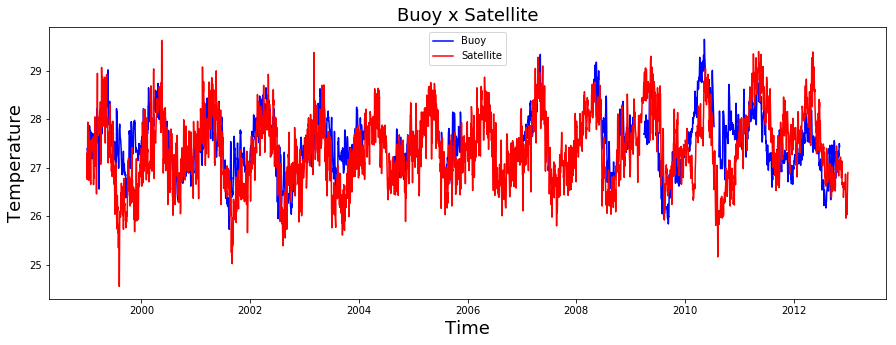

In [81]:
plt.rcParams["figure.figsize"] = (15,5)

#fig = plt.figure()

plt.plot_date(time_b3,sst1_b3, 'b-', label = 'Buoy')
plt.plot_date(time_s3,sst1_s3, 'r-', label = 'Satellite')
plt.legend(loc='upper center')

plt.title('Buoy x Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)

plt.show()

In [82]:
x3 = sst1_b3
y3 = sst1_s3

In [83]:
print(ma.corrcoef(ma.masked_invalid(x3), ma.masked_invalid(y3)))  #ignora os nan 


[[1.0 0.5426602778626247]
 [0.5426602778626247 1.0]]


In [84]:
print(ma.cov(ma.masked_invalid(x3), ma.masked_invalid(y3)))  #ignora os nan 


[[0.3727489046456852 0.2502079896170251]
 [0.2502079896170251 0.5703348440776758]]


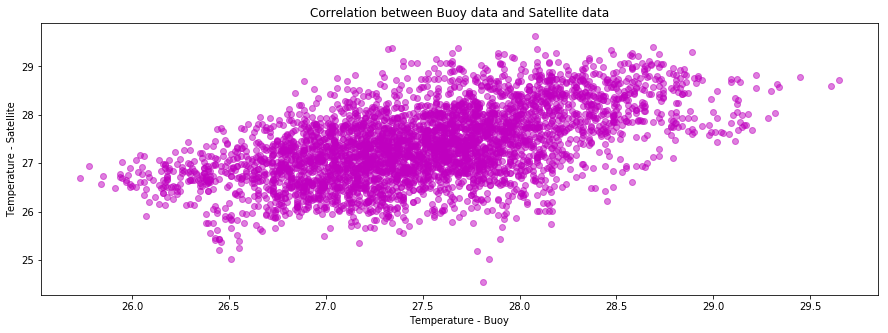

In [85]:
plt.rcParams["figure.figsize"] = (15,5)
colors = (0.75, 0, 0.75)
#colors = (1.0, 0.5, 1.0)

plt.scatter(x3, y3, c=colors, alpha=0.5) 


plt.xlabel('Temperature - Buoy')
plt.ylabel('Temperature - Satellite')
plt.title('Correlation between Buoy data and Satellite data')
plt.show()

# 4N 38W

In [88]:
satelite4 = xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/PIRATA/4n38.nc')

In [89]:
buoy4 = xr.open_dataset('http://goosbrasil.org:8080/pirata/B4n38w.nc')


In [90]:
buoy4 = buoy4.where(buoy4>0)
satelite4 = satelite4.where(satelite4>0)

In [117]:
temp_b4 = buoy4.variables['temperature'][:]
time_b4 = buoy4.variables['time'][315:7255]  # iguala o tempo da boia com a do satelite 

temp_s4 = satelite4.variables['sst'][:]
time_s4 = satelite4.variables['time'][:]

In [119]:
sst1_s4 = np.squeeze(temp_s4[:,8,8])  #redimensionar satelite, coloquei lat e lon iguais da boia 
sst1_b4 = np.squeeze(temp_b4[315:7255,0]) #escolhi a primeira profundidade que é 1 metro

In [120]:
print(time_b4.shape)
print(sst1_b4.shape)
print(time_s4.shape)
print(sst1_s4.shape)

(6940,)
(6940,)
(6940,)
(6940,)


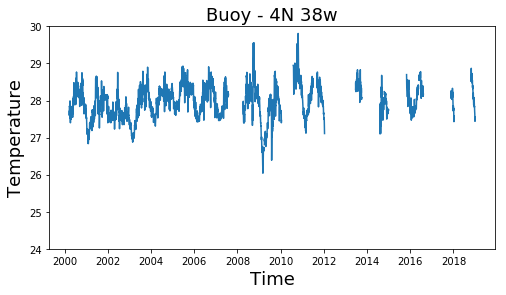

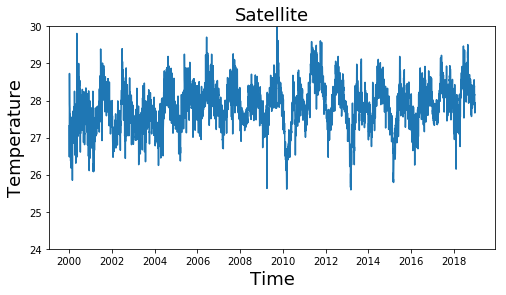

In [122]:
plt.rcParams["figure.figsize"] = (8,9)

plt.subplot(2, 1, 1)
plt.plot(time_b4,sst1_b4,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Buoy - 4N 38w', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

plt.subplot(2, 1, 2)
plt.plot(time_s4,sst1_s4,'-')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,24,30))
plt.title('Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

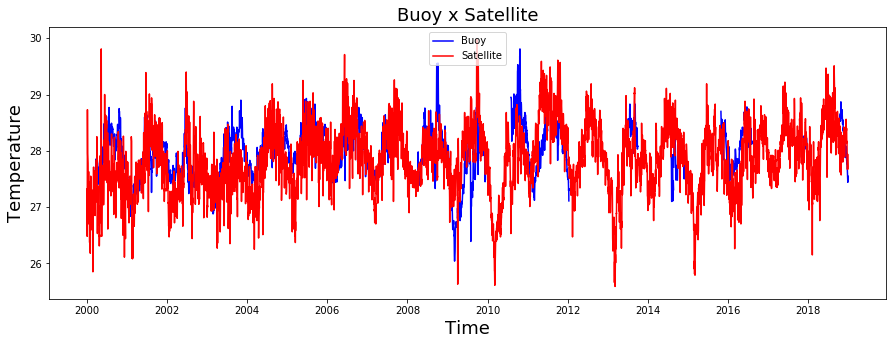

In [123]:
plt.rcParams["figure.figsize"] = (15,5)

#fig = plt.figure()

plt.plot_date(time_b4,sst1_b4, 'b-', label = 'Buoy')
plt.plot_date(time_s4,sst1_s4, 'r-', label = 'Satellite')
plt.legend(loc='upper center')

plt.title('Buoy x Satellite', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)

plt.show()

In [124]:
x4 = sst1_b4
y4 = sst1_s4

In [125]:
print(ma.corrcoef(ma.masked_invalid(x4), ma.masked_invalid(y4)))  #ignora os nan 


[[1.0 0.39438856485915647]
 [0.39438856485915647 1.0]]


In [126]:
print(ma.cov(ma.masked_invalid(x4), ma.masked_invalid(y4)))  #ignora os nan 


[[0.20093048332504052 0.0982755345418976]
 [0.0982755345418976 0.3090269617118953]]


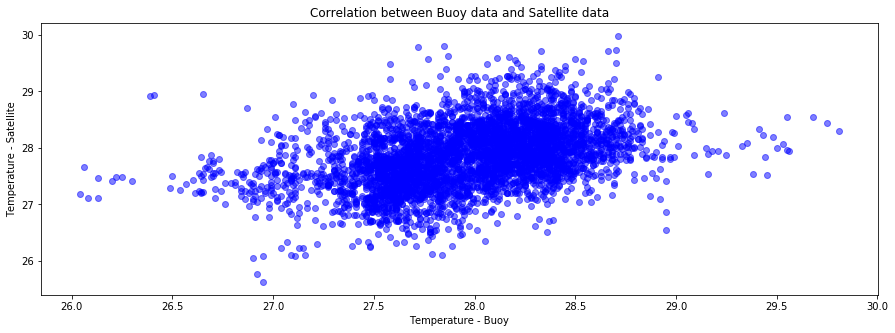

In [127]:
plt.rcParams["figure.figsize"] = (15,5)
colors = (0, 0, 1.0)
#colors = (1.0, 0.5, 1.0)

plt.scatter(x4, y4, c=colors, alpha=0.5) 


plt.xlabel('Temperature - Buoy')
plt.ylabel('Temperature - Satellite')
plt.title('Correlation between Buoy data and Satellite data')
plt.show()